# 15 - the Coinshot hover: why a steady push bobs

Notebook 02 left a loose end: Wax pushing down on an anchor does not settle
at a hover height, he oscillates around it forever. That got filed as a
'hover instability' needing some control trick. Elliott pushed back: maybe
it just oscillates because nothing damps it, and the experiment had no air.
He was right. This notebook works out why.

The short version, derived below: a push whose strength falls off linearly
with distance is a literal spring. A Coinshot holding station on an anchor
is a mass on a spring, and an undamped mass on a spring oscillates forever.
So a steady push cannot hover - not because hovering needs a trick, but
because the model had no damping term. We then add the two things that can
damp it: air drag (which we built in notebook 13), and the Coinshot
actively varying their push.

Terms used in this notebook, defined once:

- **Equilibrium height**: the height where the upward push exactly cancels
  gravity. Here it is 9.72 m above the anchor.
- **Spring constant** (k): how much the net restoring force grows per metre
  of displacement from equilibrium, in newtons per metre.
- **Simple harmonic motion**: the back-and-forth of a mass on an ideal
  spring - a clean sine wave with period 2*pi*sqrt(m/k), the same period at
  any amplitude.
- **Damping**: any force that bleeds energy out of the oscillation (drag,
  or active control), shrinking the swing over time.
- **Settling time**: how long until the oscillation has shrunk to near
  zero - our measure of whether a hover is practical.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from sim import Body, World, Steelpush, AirDrag, GRAVITY_M_PER_S2

PUSH_STRENGTH_N = 2000.0
MAX_RANGE_M = 16.0
WAX_MASS_KG = 80.0
EQUILIBRIUM_HEIGHT_M = 9.72   # where push cancels gravity (derived below)


def hover_run(start_y, kick_m_per_s=0.0, with_air=False, control=None,
              seconds=20.0):
    """Wax holding station on a fixed anchor at the origin. Optionally kick
    his vertical speed, add air drag, or hand control a HoverControl."""
    world = World()
    wax = world.add_body(Body("wax", WAX_MASS_KG, (0, start_y),
                              velocity=(0, kick_m_per_s)))
    anchor = world.add_body(Body("anchor", 0.004, (0, 0.05), radius_m=0.01,
                                 is_metal=True, is_fixed=True))
    push = Steelpush(wax, anchor, PUSH_STRENGTH_N)
    push.active = True
    if control is not None:
        control.attach(push, wax, anchor)
        world.add_power(control)   # added first, so it sets strength before the push reads it
    world.add_power(push)
    if with_air:
        world.add_power(AirDrag(world))
    world.run(seconds)
    data = world.history.body("wax")
    return np.array(data["t"]), np.array(data["y"])

## The push is a spring

The push strength falls off linearly: force = strength * (1 - d/range),
pointing away from the anchor. At the equilibrium height the push cancels
gravity: strength * (1 - d0/range) = m*g. Solve it and d0 = 9.72 m for our
numbers.

Now displace Wax by x above equilibrium. The new distance is d0 + x, so the
push becomes strength * (1 - (d0+x)/range) = m*g - (strength/range)*x. The
net force (push minus gravity) is

    F = -(strength/range) * x

which is Hooke's law with spring constant k = strength/range = 2000/16 =
125 N/m. A mass on a spring, exactly. Predicted period: 2*pi*sqrt(m/k) =
5.03 s, the same at any amplitude.

Test it: start Wax 2 m above equilibrium, no air, no control, and let go.
(Small enough that he stays inside push range the whole swing - above the
16 m range the push cuts off and the motion goes ballistic, which is why
the big launches in notebook 02 were not pure sine waves.)

spring constant k = 125 N/m
period: predicted 5.03 s, measured 5.02 s
peak heights: 11.720, 11.720, 11.720 m (constant = undamped)


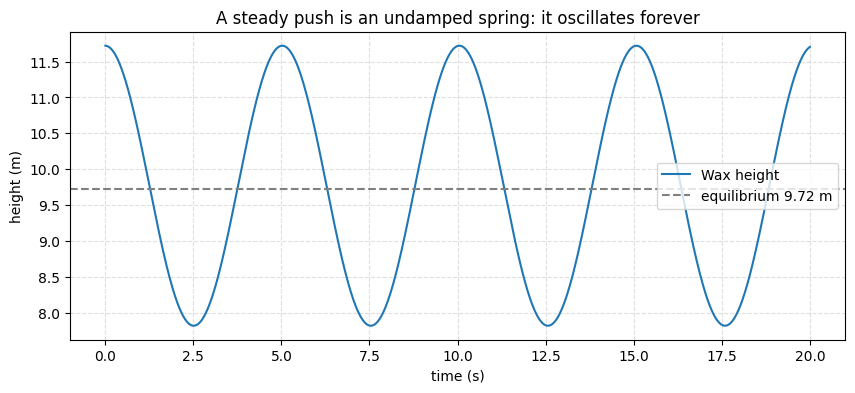

In [2]:
k = PUSH_STRENGTH_N / MAX_RANGE_M
predicted_period = 2 * np.pi * np.sqrt(WAX_MASS_KG / k)

t, y = hover_run(start_y=EQUILIBRIUM_HEIGHT_M + 2.0, seconds=20.0)

# measure the period from successive peaks
peak_idx = np.where((y[1:-1] > y[:-2]) & (y[1:-1] > y[2:]))[0] + 1
measured_period = t[peak_idx[1]] - t[peak_idx[0]]
print(f"spring constant k = {k:.0f} N/m")
print(f"period: predicted {predicted_period:.2f} s, measured {measured_period:.2f} s")
print(f"peak heights: {y[peak_idx[0]]:.3f}, {y[peak_idx[1]]:.3f}, {y[peak_idx[2]]:.3f} m "
      f"(constant = undamped)")

plt.figure(figsize=(10, 4))
plt.plot(t, y, label="Wax height")
plt.axhline(EQUILIBRIUM_HEIGHT_M, color="gray", linestyle="--", label="equilibrium 9.72 m")
plt.xlabel("time (s)")
plt.ylabel("height (m)")
plt.title("A steady push is an undamped spring: it oscillates forever")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

## Damping route 1: air drag

The spring has no damping, so it never settles. Air drag (notebook 13) is a
velocity-opposing force - the textbook damping term. Add it and the
oscillation must decay. The question is how fast, at Wax's mass and size.

air drag: swing 2.0 m -> 1.54 m over 300 s
decay time constant ~1129 s; extrapolated time to settle under 0.1 m: ~56 minutes


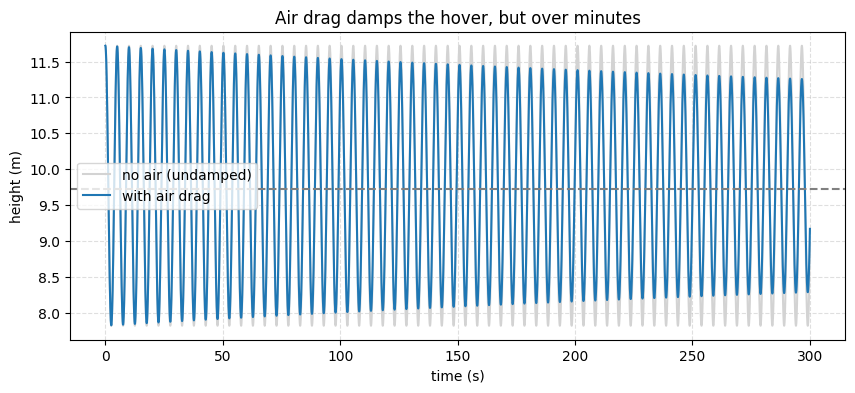

In [3]:
t_dry, y_dry = hover_run(start_y=EQUILIBRIUM_HEIGHT_M + 2.0, seconds=300.0)
t_air, y_air = hover_run(start_y=EQUILIBRIUM_HEIGHT_M + 2.0, with_air=True, seconds=300.0)

def amplitude_envelope(t, y):
    idx = np.where((y[1:-1] > y[:-2]) & (y[1:-1] > y[2:]))[0] + 1
    return t[idx], y[idx] - EQUILIBRIUM_HEIGHT_M

ta, aa = amplitude_envelope(t_air, y_air)
# fit an exponential decay to extrapolate the settling time
tau = -(ta[-1] - ta[0]) / np.log(aa[-1] / aa[0])
settle_to_10cm = tau * np.log(aa[0] / 0.1)
print(f"air drag: swing 2.0 m -> {aa[-1]:.2f} m over 300 s")
print(f"decay time constant ~{tau:.0f} s; extrapolated time to settle under "
      f"0.1 m: ~{settle_to_10cm/60:.0f} minutes")

plt.figure(figsize=(10, 4))
plt.plot(t_dry, y_dry, color="lightgray", label="no air (undamped)")
plt.plot(t_air, y_air, color="tab:blue", label="with air drag")
plt.axhline(EQUILIBRIUM_HEIGHT_M, color="gray", linestyle="--")
plt.xlabel("time (s)")
plt.ylabel("height (m)")
plt.title("Air drag damps the hover, but over minutes")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

## Damping route 2: the Coinshot modulates the push

Air drag works but takes minutes - useless for holding station in a fight.
The real answer is the obvious one once the spring picture is clear: a
Coinshot does not hold a constant push, they vary it - easing off when
rising, bearing down when falling. That is active damping.

We model it as a standard proportional-derivative controller: each tick the
Coinshot sets their push to deliver gravity's weight plus a correction that
pulls toward the target height and opposes their vertical speed. The gains
are tuning, not canon; the point is only that a modest, physically bounded
modulation turns the bob into a hover. We test it by kicking Wax downward
at his hover point and watching him recover, with and without control.

kicked downward 5 m/s at the hover point:
  no control:   still swinging at t=12 s (undamped)
  with control: back within 0.1 m of the hover by 1.7 s


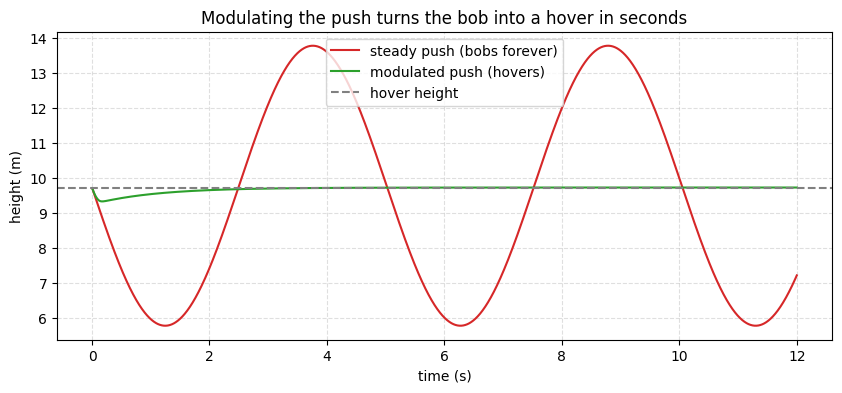

In [4]:
class HoverControl:
    """A Coinshot varying their push to hold a height. Sets push strength each
    tick to deliver weight + a pull toward the target - a damping of vertical
    speed (a proportional-derivative controller). Push strength is clamped to
    a finite maximum: steel can push, never pull, so it cannot go negative."""

    def __init__(self, target_height_m, height_gain=2000.0, speed_gain=2200.0,
                 max_strength_n=8000.0):
        self.target_height_m = target_height_m
        self.height_gain = height_gain
        self.speed_gain = speed_gain
        self.max_strength_n = max_strength_n

    def attach(self, push, body, anchor):
        self.push, self.body, self.anchor = push, body, anchor

    def apply_forces(self):
        distance = abs(self.body.position[1] - self.anchor.position[1])
        falloff = max(1e-3, 1 - distance / self.push.max_range_m)
        weight = self.body.mass_kg * GRAVITY_M_PER_S2
        desired_force = (weight
                         + self.height_gain * (self.target_height_m - self.body.position[1])
                         - self.speed_gain * self.body.velocity[1])
        # realize the desired force by choosing the push strength for it
        self.push.strength_newtons = float(np.clip(desired_force / falloff,
                                                    0.0, self.max_strength_n))


t_free, y_free = hover_run(start_y=EQUILIBRIUM_HEIGHT_M, kick_m_per_s=-5.0, seconds=12.0)
t_ctrl, y_ctrl = hover_run(start_y=EQUILIBRIUM_HEIGHT_M, kick_m_per_s=-5.0,
                           control=HoverControl(EQUILIBRIUM_HEIGHT_M), seconds=12.0)

settled = next(t_ctrl[i] for i in range(len(y_ctrl))
               if np.all(np.abs(y_ctrl[i:] - EQUILIBRIUM_HEIGHT_M) < 0.1))
print(f"kicked downward 5 m/s at the hover point:")
print(f"  no control:   still swinging at t=12 s (undamped)")
print(f"  with control: back within 0.1 m of the hover by {settled:.1f} s")

plt.figure(figsize=(10, 4))
plt.plot(t_free, y_free, color="tab:red", label="steady push (bobs forever)")
plt.plot(t_ctrl, y_ctrl, color="tab:green", label="modulated push (hovers)")
plt.axhline(EQUILIBRIUM_HEIGHT_M, color="gray", linestyle="--", label="hover height")
plt.xlabel("time (s)")
plt.ylabel("height (m)")
plt.title("Modulating the push turns the bob into a hover in seconds")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

## Findings

1. **A steady push is an undamped spring.** Linear falloff makes the net
   force a Hooke's-law restoring force, k = strength/range = 125 N/m. Small
   oscillations are pure simple harmonic motion: predicted period 5.03 s,
   measured 5.02 s, amplitude dead constant. So a constant push cannot
   hover - it bobs forever. The 'hover instability' was just a missing
   damping term, exactly as Elliott suspected; nothing about it needs a
   special trick.
2. **Air drag damps it, but over minutes.** With the air from notebook 13,
   a 2 m swing falls to 1.5 m in 300 s and would take tens of minutes to
   settle. Real, but far too slow to hold station in a fight.
3. **Modulating the push hovers in seconds.** A Coinshot easing off when
   rising and bearing down when falling (a proportional-derivative control)
   recovers a 5 m/s downward kick to within 0.1 m of the hover in under
   2 s. Hovering is an active skill, not an automatic property of pushing -
   which fits the books, where holding a precise position is something
   skilled Coinshots do, not a given.
4. **Modeling notes.** The push range cuts the spring off above 16 m, so
   large launches go ballistic at the top (why notebook 02's big bounces
   were not clean sines). The linear falloff is our choice; canon suggests
   push weakens roughly as 1/distance, which would make a softer, anharmonic
   spring - still oscillating, just not a clean sine. The controller gains
   are tuning, and the push is clamped to a finite maximum because steel
   pushes and never pulls.

Next in the steel arc: notebook 16 - the steel reserve and flaring (a
finite metal budget, and burning it harder for a bigger push).